In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [3]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    
    equation: str
    discriminant: float
    result: float

In [4]:
def show_equation(state: QuadState) -> QuadState:
    equation = f"{state['a']}x² + {state['b']}x + {state['c']} = 0"
    return {"equation": equation}

In [5]:
def calc_disc(state: QuadState) -> QuadState:
    disc = (state['b'] ** 2) - 4 * (state['a'] * state['c'])
    return {'discriminant': disc} 

In [6]:
def real_r(state: QuadState) -> QuadState:
    r1 = (-state['b'] + (state['discriminant'] ** 0.5)) / 2 * state['a']
    r2 = (-state['b'] - (state['discriminant'] ** 0.5)) / 2 * state['a']
    res = f"The two roots are {r1} and {r2}"
    return {'result': res}

In [7]:
def repeated_r(state: QuadState) -> QuadState:
    r1 = -state['b'] / 2 * state['a']
    res = f"The two roots are {r1} and {r1}"
    return {'result': res}

In [8]:
def no_r(state: QuadState) -> QuadState:
    res = f"There are no real roots for this eqn"
    return {'result': res}

In [9]:
def check_condition(state: QuadState) -> Literal['real_root', 'no_root', 'repeated_root']:
    if state['discriminant'] > 0:
        return 'real_root'
    elif state['discriminant'] == 0:
        return 'repeated_root'
    else:
        return 'no_root'
    

In [10]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calc_disc', calc_disc)
graph.add_node('real_root', real_r)
graph.add_node('no_root', no_r)
graph.add_node('repeated_root', repeated_r)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calc_disc')

graph.add_conditional_edges('calc_disc', check_condition)

graph.add_edge('real_root', END)
graph.add_edge('repeated_root', END)
graph.add_edge('no_root', END)

workflow = graph.compile()

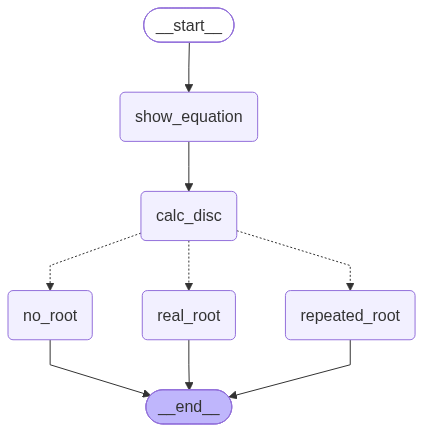

In [11]:
workflow

In [12]:
intial_state = {'a': 12, 'b': 20, 'c': 30}
final_state = workflow.invoke(intial_state)

In [13]:
print(final_state)

{'a': 12, 'b': 20, 'c': 30, 'equation': '12x² + 20x + 30 = 0', 'discriminant': -1040, 'result': 'There are no real roots for this eqn'}
